# Trabajo Práctico N.º 3
## Clasificación de informalidad laboral en la EPH

**Materia:** Taller de Programación  
**Institución:** Universidad de Buenos Aires  
**Grupo:** Grupo 1  
**Períodos:** IV trimestre de 2024 y IV trimestre de 2025  

### A. Enfoque de validación
Se utiliza 2024T4 como muestra de entrenamiento (train) y 2025T4 como
muestra de testeo (test). La variable objetivo identifica a los asalariados
informales según la definición empleada desde el TP1.

In [1]:
# ============================================================
# TP3 - Taller de Programación
# 0. Librerías y carga de bases
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 50)

# ------------------------------------------------------------
# Archivos
# ------------------------------------------------------------

ruta_2024 = Path("/content/usu_individual_T424.xlsx")
ruta_2025 = Path("/content/usu_individual_T425.xlsx")

print("Existe archivo 2024:", ruta_2024.exists())
print("Existe archivo 2025:", ruta_2025.exists())

Existe archivo 2024: True
Existe archivo 2025: True


In [2]:
# ============================================================
# 0.1 Selección y carga de variables
# ============================================================

variables_id = [
    "CODUSU",
    "ANO4",
    "TRIMESTRE",
    "NRO_HOGAR",
    "COMPONENTE",
    "PONDERA"
]

variables_base = [
    # Sociodemográficas
    "CH04",          # sexo
    "CH06",          # edad
    "CH08",          # cobertura médica

    # Educación
    "CH12",
    "CH13",
    "CH14",

    # Situación laboral
    "ESTADO",
    "CAT_OCUP",
    "PP04C",
    "PP07H",

    # Horas trabajadas
    "PP3E_TOT",
    "PP3F_TOT",

    # Ingreso
    "P21"
]

variables = variables_id + variables_base

df_2024 = pd.read_excel(
    ruta_2024,
    usecols=variables,
    dtype={"CODUSU": "string"}
)

df_2025 = pd.read_excel(
    ruta_2025,
    usecols=variables,
    dtype={"CODUSU": "string"}
)

# Año/período
df_2024["PERIODO"] = "2024T4"
df_2025["PERIODO"] = "2025T4"

print("Dimensión 2024:", df_2024.shape)
print("Dimensión 2025:", df_2025.shape)

Dimensión 2024: (46860, 20)
Dimensión 2025: (43703, 20)


In [3]:
print("2024")
display(df_2024.head())

print("\n2025")
display(df_2025.head())

print("\nAños:")
print(df_2024["ANO4"].value_counts(dropna=False))
print(df_2025["ANO4"].value_counts(dropna=False))

print("\nTrimestres:")
print(df_2024["TRIMESTRE"].value_counts(dropna=False))
print(df_2025["TRIMESTRE"].value_counts(dropna=False))

2024


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,PONDERA,CH04,CH06,CH08,CH12,CH13,CH14,ESTADO,CAT_OCUP,PP3E_TOT,PP3F_TOT,PP04C,PP07H,P21,PERIODO
0,TQRMNORTSHJKLMCDEHPJB00872828,2024,4,1,2,384,1,79,1,6,1,NaN,3,0,NaN,NaN,NaN,NaN,0,2024T4
1,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,1,265,2,23,1,7,2,2.0,3,0,NaN,NaN,NaN,NaN,0,2024T4
2,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,2,265,2,20,4,7,2,0.0,3,0,NaN,NaN,NaN,NaN,0,2024T4
3,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,1,380,1,30,1,6,1,NaN,1,3,70.0,0.0,9.0,1.0,1000000,2024T4
4,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,2,380,2,30,1,6,1,NaN,1,3,30.0,0.0,12.0,1.0,500000,2024T4



2025


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,PONDERA,CH04,CH06,CH08,CH12,CH13,CH14,ESTADO,CAT_OCUP,PP3E_TOT,PP3F_TOT,PP04C,PP07H,P21,PERIODO
0,TQRMNORSVHLMKRCDEHIBB00896088,2025,4,1,1,228,1,46,1,7,1,NaN,1,3,48.0,30.0,10.0,1.0,2800000,2025T4
1,TQRMNORSVHLMKRCDEHIBB00896088,2025,4,1,2,228,2,46,1,7,1,NaN,1,3,30.0,30.0,10.0,1.0,2000000,2025T4
2,TQRMNORSVHLMKRCDEHIBB00896088,2025,4,1,3,228,1,8,1,2,2,3.0,4,0,NaN,NaN,NaN,NaN,0,2025T4
3,TQRMNORSWHLMKRCDEHIBB00893062,2025,4,1,1,113,1,55,2,7,1,NaN,1,2,40.0,30.0,3.0,0.0,700000,2025T4
4,TQRMNORSWHLMKRCDEHIBB00893062,2025,4,1,2,113,2,52,2,7,1,NaN,1,2,40.0,24.0,3.0,0.0,700000,2025T4



Años:
ANO4
2024    46860
Name: count, dtype: int64
ANO4
2025    43703
Name: count, dtype: int64

Trimestres:
TRIMESTRE
4    46860
Name: count, dtype: int64
TRIMESTRE
4    43703
Name: count, dtype: int64


In [4]:
# ============================================================
# TP3 - Reconstrucción de la base ocupados
# Variables heredadas del TP2
# ============================================================

# Unimos 2024 y 2025
base = pd.concat([df_2024, df_2025], ignore_index=True)

# ------------------------------------------------------------
# 1. Edad y edad al cuadrado
# ------------------------------------------------------------

base["edad"] = pd.to_numeric(base["CH06"], errors="coerce").astype("Float64")
base["edad2"] = base["edad"] ** 2


# ------------------------------------------------------------
# 2. Número de integrantes del hogar
# Se calcula ANTES de seleccionar ocupados, porque deben contarse
# todos los miembros del hogar.
# ------------------------------------------------------------

base["nhogar"] = (
    base.groupby(
        ["PERIODO", "CODUSU", "NRO_HOGAR"]
    )["COMPONENTE"]
    .transform("nunique")
    .astype("Int64")
)


# ------------------------------------------------------------
# 3. Años de educación
# Misma construcción utilizada en el TP2
# ------------------------------------------------------------

base["CH12_limpia"] = (
    base["CH12"]
    .replace({0: np.nan, 99: np.nan})
    .astype("Float64")
)

base["CH13_limpia"] = (
    base["CH13"]
    .replace({0: np.nan, 9: np.nan})
    .astype("Float64")
)

base["CH14_limpia"] = (
    base["CH14"]
    .replace({98: np.nan, 99: np.nan})
    .astype("Float64")
)

# Años acumulados antes de comenzar cada nivel
anios_previos = {
    1: 0,    # Jardín / preescolar
    2: 0,    # Primario
    3: 0,    # EGB
    4: 6,    # Secundario
    5: 9,    # Polimodal
    6: 12,   # Terciario
    7: 12,   # Universitario
    8: 17    # Posgrado universitario
}

# Años imputados cuando el nivel fue completado
anios_nivel_completo = {
    1: 0,
    2: 6,
    3: 9,
    4: 12,
    5: 12,
    6: 15,
    7: 17,
    8: 18
}

base["educ"] = np.nan

# Nivel incompleto
mask_incompleto = (
    base["CH13_limpia"].eq(2)
    & base["CH12_limpia"].isin(anios_previos)
    & base["CH14_limpia"].between(0, 9)
)

base.loc[mask_incompleto, "educ"] = (
    base.loc[mask_incompleto, "CH12_limpia"].map(anios_previos)
    + base.loc[mask_incompleto, "CH14_limpia"]
)

# Nivel completo
mask_completo = (
    base["CH13_limpia"].eq(1)
    & base["CH12_limpia"].isin(anios_nivel_completo)
)

base.loc[mask_completo, "educ"] = (
    base.loc[mask_completo, "CH12_limpia"]
    .map(anios_nivel_completo)
)

base["educ"] = base["educ"].astype("Float64")


# ------------------------------------------------------------
# 4. Horas trabajadas
# ------------------------------------------------------------

base["PP3E_limpia"] = (
    base["PP3E_TOT"]
    .replace({999: np.nan})
    .astype("Float64")
)

base["PP3F_limpia"] = (
    base["PP3F_TOT"]
    .replace({999: np.nan})
    .astype("Float64")
)

base["horastrab"] = (
    base[["PP3E_limpia", "PP3F_limpia"]]
    .sum(axis=1, min_count=1)
    .astype("Float64")
)

# Una semana no puede superar 168 horas
base.loc[base["horastrab"] > 168, "horastrab"] = np.nan


# ------------------------------------------------------------
# 5. Selección de ocupados
# ------------------------------------------------------------

ocupados = base.loc[
    base["ESTADO"].eq(1)
].copy()

print("Ocupados por período:")
display(
    ocupados.groupby("PERIODO")
    .size()
    .rename("ocupados")
    .to_frame()
)

Ocupados por período:


,ocupados
PERIODO,
2024T4,21132
2025T4,19698


In [5]:
# ============================================================
# Variable objetivo: informalidad
# ============================================================

# NA = ocupado fuera del universo de asalariados clasificables
ocupados["informal"] = pd.Series(
    pd.NA,
    index=ocupados.index,
    dtype="Int64"
)

# Formal: asalariado CON descuento jubilatorio
ocupados.loc[
    ocupados["CAT_OCUP"].eq(3)
    & ocupados["PP07H"].eq(1),
    "informal"
] = 0

# Informal: asalariado SIN descuento jubilatorio
ocupados.loc[
    ocupados["CAT_OCUP"].eq(3)
    & ocupados["PP07H"].eq(2),
    "informal"
] = 1


# Base efectivamente clasificable
ocupados_modelo = ocupados.loc[
    ocupados["informal"].notna()
].copy()


# Control
control_informalidad = (
    ocupados_modelo
    .groupby(["PERIODO", "informal"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Formales", 1: "Informales"})
)

control_informalidad["Total"] = control_informalidad.sum(axis=1)
control_informalidad["% informal"] = (
    100
    * control_informalidad["Informales"]
    / control_informalidad["Total"]
).round(1)

display(control_informalidad)

informal,Formales,Informales,Total,% informal
PERIODO,,,,
2024T4,9727,5565,15292,36.4
2025T4,8815,5128,13943,36.8


In [6]:
# ============================================================
# TP3 - Variables binarias candidatas para la matriz X
# ============================================================

# ------------------------------------------------------------
# 1. Mujer
# CH04: 1 = varón, 2 = mujer
# Categoría de referencia: varón
# ------------------------------------------------------------

ocupados_modelo["mujer"] = pd.Series(
    pd.NA,
    index=ocupados_modelo.index,
    dtype="Int64"
)

ocupados_modelo.loc[
    ocupados_modelo["CH04"].eq(1),
    "mujer"
] = 0

ocupados_modelo.loc[
    ocupados_modelo["CH04"].eq(2),
    "mujer"
] = 1


# ------------------------------------------------------------
# 2. Cobertura médica
# 1 = tiene cobertura
# 0 = no tiene cobertura
# ------------------------------------------------------------

ocupados_modelo["con_cobertura_medica"] = (
    ocupados_modelo["CH08"]
    .map({
        1: 1,
        2: 1,
        3: 1,
        4: 0,
        12: 1,
        13: 1,
        23: 1,
        123: 1
    })
    .astype("Int64")
)


# ------------------------------------------------------------
# 3. Establecimiento de hasta 5 personas
# PP04C 1 a 5 -> establecimiento pequeño
# PP04C 6 a 12 -> establecimiento mayor
# ------------------------------------------------------------

ocupados_modelo["empresa_hasta_5"] = pd.Series(
    pd.NA,
    index=ocupados_modelo.index,
    dtype="Int64"
)

ocupados_modelo.loc[
    ocupados_modelo["PP04C"].between(1, 5),
    "empresa_hasta_5"
] = 1

ocupados_modelo.loc[
    ocupados_modelo["PP04C"].between(6, 12),
    "empresa_hasta_5"
] = 0

In [7]:
# ============================================================
# Auditoría preliminar de variables candidatas
# ============================================================

variables_candidatas = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "mujer",
    "con_cobertura_medica",
    "empresa_hasta_5"
]

auditoria_X = pd.DataFrame({
    "N_validos": ocupados_modelo[variables_candidatas].notna().sum(),
    "N_faltantes": ocupados_modelo[variables_candidatas].isna().sum(),
    "%_faltantes": (
        ocupados_modelo[variables_candidatas]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    "N_unicos": ocupados_modelo[variables_candidatas].nunique()
})

display(auditoria_X)

,N_validos,N_faltantes,%_faltantes,N_unicos
edad,29235,0,0.00,79
edad2,29235,0,0.00,79
educ,28889,346,1.18,23
horastrab,29214,21,0.07,117
nhogar,29235,0,0.00,17
mujer,29235,0,0.00,2
con_cobertura_medica,29207,28,0.10,2
empresa_hasta_5,21190,8045,27.52,2


In [8]:
# Control por año
for periodo in ["2024T4", "2025T4"]:

    print(f"\n===== {periodo} =====")

    temp = ocupados_modelo.loc[
        ocupados_modelo["PERIODO"].eq(periodo),
        variables_candidatas
    ]

    control = pd.DataFrame({
        "N_validos": temp.notna().sum(),
        "N_faltantes": temp.isna().sum(),
        "%_faltantes": (temp.isna().mean() * 100).round(2)
    })

    display(control)


===== 2024T4 =====


,N_validos,N_faltantes,%_faltantes
edad,15292,0,0.00
edad2,15292,0,0.00
educ,15126,166,1.09
horastrab,15280,12,0.08
nhogar,15292,0,0.00
mujer,15292,0,0.00
con_cobertura_medica,15280,12,0.08
empresa_hasta_5,11233,4059,26.54



===== 2025T4 =====


,N_validos,N_faltantes,%_faltantes
edad,13943,0,0.00
edad2,13943,0,0.00
educ,13763,180,1.29
horastrab,13934,9,0.06
nhogar,13943,0,0.00
mujer,13943,0,0.00
con_cobertura_medica,13927,16,0.11
empresa_hasta_5,9957,3986,28.59


In [9]:
# ============================================================
# A.1 - Definición de variables X
# ============================================================

X_vars = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "mujer",
    "con_cobertura_medica"
]

id_vars = [
    "CODUSU",
    "NRO_HOGAR",
    "COMPONENTE"
]

target = "informal"

print("Variables utilizadas en X:")
print(X_vars)

Variables utilizadas en X:
['edad', 'edad2', 'educ', 'horastrab', 'nhogar', 'mujer', 'con_cobertura_medica']


In [10]:
# ============================================================
# A.1 - Separación temporal
# 2024 = entrenamiento
# 2025 = testeo
# ============================================================

base_2024 = ocupados_modelo.loc[
    ocupados_modelo["PERIODO"].eq("2024T4"),
    id_vars + X_vars + [target]
].copy()

base_2025 = ocupados_modelo.loc[
    ocupados_modelo["PERIODO"].eq("2025T4"),
    id_vars + X_vars + [target]
].copy()

print("Base 2024 antes de eliminar faltantes:", base_2024.shape)
print("Base 2025 antes de eliminar faltantes:", base_2025.shape)

Base 2024 antes de eliminar faltantes: (15292, 11)
Base 2025 antes de eliminar faltantes: (13943, 11)


In [11]:
# ============================================================
# Control de casos completos
# ============================================================

base_2024_cc = base_2024.dropna(
    subset=X_vars + [target]
).copy()

base_2025_cc = base_2025.dropna(
    subset=X_vars + [target]
).copy()

print("2024")
print("Original:", len(base_2024))
print("Casos completos:", len(base_2024_cc))
print(
    "Pérdida:",
    round(100 * (1 - len(base_2024_cc) / len(base_2024)), 2),
    "%"
)

print("\n2025")
print("Original:", len(base_2025))
print("Casos completos:", len(base_2025_cc))
print(
    "Pérdida:",
    round(100 * (1 - len(base_2025_cc) / len(base_2025)), 2),
    "%"
)

2024
Original: 15292
Casos completos: 15104
Pérdida: 1.23 %

2025
Original: 13943
Casos completos: 13743
Pérdida: 1.43 %


In [12]:
# ============================================================
# Matrices X y vectores y
# ============================================================

ocupados_X_2024 = (
    base_2024_cc[X_vars]
    .astype(float)
    .copy()
)

ocupados_X_2025 = (
    base_2025_cc[X_vars]
    .astype(float)
    .copy()
)

y_2024 = (
    base_2024_cc[target]
    .astype(int)
    .copy()
)

y_2025 = (
    base_2025_cc[target]
    .astype(int)
    .copy()
)

print("X 2024:", ocupados_X_2024.shape)
print("y 2024:", y_2024.shape)

print("\nX 2025:", ocupados_X_2025.shape)
print("y 2025:", y_2025.shape)

X 2024: (15104, 7)
y 2024: (15104,)

X 2025: (13743, 7)
y 2025: (13743,)


In [13]:
# ============================================================
# Control de unicidad de identificadores
# ============================================================

print(
    "Duplicados ID 2024:",
    base_2024_cc.duplicated(subset=id_vars).sum()
)

print(
    "Duplicados ID 2025:",
    base_2025_cc.duplicated(subset=id_vars).sum()
)

Duplicados ID 2024: 0
Duplicados ID 2025: 0


In [14]:
# ============================================================
# Construcción de la muestra Maurizio & Monsalvo
# Misma persona observada en 2024 y 2025
# ============================================================

# Informalidad observada en 2024
informal_2024 = (
    base_2024_cc[
        id_vars + ["informal"]
    ]
    .rename(columns={
        "informal": "informal_2024"
    })
    .copy()
)

# Datos 2025 + informalidad de la misma persona en 2024
ocupados_2025_MM = base_2025_cc.merge(
    informal_2024,
    on=id_vars,
    how="inner",
    validate="one_to_one"
)

print("Observaciones 2025 antes del inner join:", len(base_2025_cc))
print("Observaciones emparejadas 2024-2025:", len(ocupados_2025_MM))

print(
    "% de la muestra 2025 recuperada:",
    round(
        100 * len(ocupados_2025_MM) / len(base_2025_cc),
        2
    ),
    "%"
)

Observaciones 2025 antes del inner join: 13743
Observaciones emparejadas 2024-2025: 4714
% de la muestra 2025 recuperada: 34.3 %


In [15]:
# ============================================================
# X e y para la especificación Maurizio & Monsalvo
# ============================================================

X_vars_MM = X_vars + ["informal_2024"]

ocupados_X_2025_MM = (
    ocupados_2025_MM[X_vars_MM]
    .astype(float)
    .copy()
)

y_2025_MM = (
    ocupados_2025_MM["informal"]
    .astype(int)
    .copy()
)

print("X 2025 MM:", ocupados_X_2025_MM.shape)
print("y 2025 MM:", y_2025_MM.shape)

display(ocupados_X_2025_MM.head())

X 2025 MM: (4714, 8)
y 2025 MM: (4714,)


,edad,edad2,educ,horastrab,nhogar,mujer,con_cobertura_medica,informal_2024
0,30.0,900.0,12.0,40.0,3.0,0.0,1.0,0.0
1,58.0,3364.0,17.0,45.0,3.0,1.0,1.0,0.0
2,51.0,2601.0,10.0,60.0,4.0,0.0,1.0,0.0
3,52.0,2704.0,8.0,32.0,4.0,0.0,1.0,0.0
4,43.0,1849.0,12.0,30.0,8.0,1.0,1.0,0.0


In [16]:
# ============================================================
# A.1 - Diagnóstico de la muestra longitudinal
# ============================================================

# 1. Asalariados clasificables ANTES de exigir casos completos
ids_2024_raw = (
    ocupados_modelo.loc[
        ocupados_modelo["PERIODO"].eq("2024T4"),
        id_vars + ["informal"]
    ]
    .copy()
)

ids_2025_raw = (
    ocupados_modelo.loc[
        ocupados_modelo["PERIODO"].eq("2025T4"),
        id_vars + ["informal"]
    ]
    .copy()
)

# 2. Personas que aparecen en ambos años antes del filtro de X completo
panel_raw = ids_2025_raw.merge(
    ids_2024_raw,
    on=id_vars,
    how="inner",
    suffixes=("_2025", "_2024"),
    validate="one_to_one"
)

# 3. Resumen
diagnostico_panel = pd.DataFrame({
    "Etapa": [
        "Asalariados clasificables 2024",
        "Asalariados clasificables 2025",
        "Coincidencias 2024-2025 antes de casos completos",
        "Coincidencias finales MM"
    ],
    "N": [
        len(ids_2024_raw),
        len(ids_2025_raw),
        len(panel_raw),
        len(ocupados_2025_MM)
    ]
})

display(diagnostico_panel)

print(
    "% coincidencia antes de casos completos sobre 2025:",
    round(100 * len(panel_raw) / len(ids_2025_raw), 2),
    "%"
)

print(
    "% coincidencia final MM sobre 2025:",
    round(100 * len(ocupados_2025_MM) / len(ids_2025_raw), 2),
    "%"
)

print(
    "Pérdida adicional por requerir X completa:",
    len(panel_raw) - len(ocupados_2025_MM),
    "personas"
)

,Etapa,N
0,Asalariados clasificables 2024,15292
1,Asalariados clasificables 2025,13943
2,Coincidencias 2024-2025 antes de casos completos,4819
3,Coincidencias finales MM,4714


% coincidencia antes de casos completos sobre 2025: 34.56 %
% coincidencia final MM sobre 2025: 33.81 %
Pérdida adicional por requerir X completa: 105 personas


In [17]:
# ============================================================
# Matriz descriptiva de transición laboral 2024 -> 2025
# ============================================================

transiciones = pd.crosstab(
    ocupados_2025_MM["informal_2024"],
    ocupados_2025_MM["informal"],
    margins=True
)

transiciones.index = ["Formal 2024", "Informal 2024", "Total"]
transiciones.columns = ["Formal 2025", "Informal 2025", "Total"]

display(transiciones)

,Formal 2025,Informal 2025,Total
Formal 2024,3117,200,3317
Informal 2024,238,1159,1397
Total,3355,1359,4714


In [18]:
transiciones_pct = pd.crosstab(
    ocupados_2025_MM["informal_2024"],
    ocupados_2025_MM["informal"],
    normalize="index"
).mul(100).round(1)

transiciones_pct.index = ["Formal 2024", "Informal 2024"]
transiciones_pct.columns = ["Formal 2025", "Informal 2025"]

display(transiciones_pct)

,Formal 2025,Informal 2025
Formal 2024,94.0,6.0
Informal 2024,17.0,83.0


In [19]:
# ============================================================
# A.1 - Transiciones de informalidad 2024 -> 2025
# ============================================================

transiciones = pd.crosstab(
    ocupados_2025_MM["informal_2024"],
    ocupados_2025_MM["informal"],
    margins=True
)

transiciones.index = [
    "Formal 2024",
    "Informal 2024",
    "Total"
]

transiciones.columns = [
    "Formal 2025",
    "Informal 2025",
    "Total"
]

display(transiciones)

,Formal 2025,Informal 2025,Total
Formal 2024,3117,200,3317
Informal 2024,238,1159,1397
Total,3355,1359,4714


In [20]:
# Porcentajes condicionados al estado de 2024

transiciones_pct = pd.crosstab(
    ocupados_2025_MM["informal_2024"],
    ocupados_2025_MM["informal"],
    normalize="index"
).mul(100).round(1)

transiciones_pct.index = [
    "Formal 2024",
    "Informal 2024"
]

transiciones_pct.columns = [
    "Formal 2025",
    "Informal 2025"
]

display(transiciones_pct)

,Formal 2025,Informal 2025
Formal 2024,94.0,6.0
Informal 2024,17.0,83.0


In [21]:
from scipy import stats

In [22]:
# ============================================================
# A.2 - Balance Table: Train 2024 vs Test 2025
# ============================================================

filas = []

for var in X_vars:

    x24 = ocupados_X_2024[var].dropna()
    x25 = ocupados_X_2025[var].dropna()

    media_24 = x24.mean()
    media_25 = x25.mean()

    # Diferencia: 2025 - 2024
    diferencia = media_25 - media_24

    # Test t de Welch
    test = stats.ttest_ind(
        x25,
        x24,
        equal_var=False,
        nan_policy="omit"
    )

    pvalue = test.pvalue

    # Estrellas de significatividad
    if pvalue < 0.01:
        sig = "***"
    elif pvalue < 0.05:
        sig = "**"
    elif pvalue < 0.10:
        sig = "*"
    else:
        sig = ""

    filas.append({
        "Variable": var,
        "Media 2024": media_24,
        "Media 2025": media_25,
        "Diferencia (25-24)": diferencia,
        "t": test.statistic,
        "p-valor": pvalue,
        "Sig.": sig
    })

balance_table = pd.DataFrame(filas)

display(
    balance_table.style.format({
        "Media 2024": "{:.3f}",
        "Media 2025": "{:.3f}",
        "Diferencia (25-24)": "{:.3f}",
        "t": "{:.3f}",
        "p-valor": "{:.4f}"
    })
)

,Variable,Media 2024,Media 2025,Diferencia (25-24),t,p-valor,Sig.
0,edad,40.025,40.485,0.460,3.113,0.0019,***
1,edad2,1757.469,1798.351,40.882,3.241,0.0012,***
2,educ,12.195,12.196,0.001,0.016,0.9876,
3,horastrab,37.505,37.682,0.177,0.957,0.3385,
4,nhogar,3.570,3.539,-0.031,-1.455,0.1456,
5,mujer,0.471,0.473,0.002,0.339,0.7348,
6,con_cobertura_medica,0.769,0.764,-0.004,-0.861,0.3894,


In [23]:
nombres_variables = {
    "edad": "Edad",
    "edad2": "Edad²",
    "educ": "Años de educación",
    "horastrab": "Horas trabajadas",
    "nhogar": "Integrantes del hogar",
    "mujer": "Mujer",
    "con_cobertura_medica": "Con cobertura médica"
}

balance_table["Variable"] = (
    balance_table["Variable"]
    .map(nombres_variables)
)

display(
    balance_table.style.format({
        "Media 2024": "{:.3f}",
        "Media 2025": "{:.3f}",
        "Diferencia (25-24)": "{:.3f}",
        "t": "{:.3f}",
        "p-valor": "{:.4f}"
    })
)

,Variable,Media 2024,Media 2025,Diferencia (25-24),t,p-valor,Sig.
0,Edad,40.025,40.485,0.460,3.113,0.0019,***
1,Edad²,1757.469,1798.351,40.882,3.241,0.0012,***
2,Años de educación,12.195,12.196,0.001,0.016,0.9876,
3,Horas trabajadas,37.505,37.682,0.177,0.957,0.3385,
4,Integrantes del hogar,3.570,3.539,-0.031,-1.455,0.1456,
5,Mujer,0.471,0.473,0.002,0.339,0.7348,
6,Con cobertura médica,0.769,0.764,-0.004,-0.861,0.3894,


In [24]:
# Diferencia relativa respecto de la media 2024
balance_table["Dif. % sobre 2024"] = (
    100
    * balance_table["Diferencia (25-24)"]
    / balance_table["Media 2024"]
)

display(
    balance_table.style.format({
        "Media 2024": "{:.3f}",
        "Media 2025": "{:.3f}",
        "Diferencia (25-24)": "{:.3f}",
        "Dif. % sobre 2024": "{:.2f}%",
        "t": "{:.3f}",
        "p-valor": "{:.4f}"
    })
)

,Variable,Media 2024,Media 2025,Diferencia (25-24),t,p-valor,Sig.,Dif. % sobre 2024
0,Edad,40.025,40.485,0.460,3.113,0.0019,***,1.15%
1,Edad²,1757.469,1798.351,40.882,3.241,0.0012,***,2.33%
2,Años de educación,12.195,12.196,0.001,0.016,0.9876,,0.01%
3,Horas trabajadas,37.505,37.682,0.177,0.957,0.3385,,0.47%
4,Integrantes del hogar,3.570,3.539,-0.031,-1.455,0.1456,,-0.85%
5,Mujer,0.471,0.473,0.002,0.339,0.7348,,0.42%
6,Con cobertura médica,0.769,0.764,-0.004,-0.861,0.3894,,-0.56%



### Lectura de la tabla de balance

Las muestras de entrenamiento (2024T4) y testeo (2025T4) presentan una elevada
estabilidad en las características observadas. No se registran diferencias
estadísticamente significativas en años de educación, horas trabajadas,
integrantes del hogar ni proporción de mujeres.

La edad media aumenta de 40,03 a 40,49 años. Aunque la diferencia es
estadísticamente significativa, su magnitud es pequeña: 0,46 años, equivalente
a 1,15% de la media de 2024. La diferencia en edad² refleja esencialmente el
mismo cambio, dado que se trata de una transformación de la edad.

En conjunto, no se observan diferencias sustantivas en las covariables
consideradas que sugieran un cambio importante en la composición observable
entre train y test.


In [25]:
# ============================================================
# B.1 - Regresión Logística
# Modelo 1: características observables - Train 2024
# ============================================================

import statsmodels.api as sm

# Agregamos constante
X_2024_logit = sm.add_constant(
    ocupados_X_2024.astype(float)
)

y_2024_logit = y_2024.astype(float)

# Estimación
modelo_1 = sm.Logit(
    y_2024_logit,
    X_2024_logit
).fit()

print(modelo_1.summary())

Optimization terminated successfully.
         Current function value: 0.315112
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               informal   No. Observations:                15104
Model:                          Logit   Df Residuals:                    15096
Method:                           MLE   Df Model:                            7
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                  0.5183
Time:                        20:13:20   Log-Likelihood:                -4759.5
converged:                       True   LL-Null:                       -9880.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   13.2325      0.413     32.002      0.000      12.422      14.04

In [26]:
# ============================================================
# Modelo 2 - Especificación Maurizio & Monsalvo
# ============================================================

X_2025_MM_logit = sm.add_constant(
    ocupados_X_2025_MM.astype(float)
)

y_2025_MM_logit = y_2025_MM.astype(float)

modelo_2 = sm.Logit(
    y_2025_MM_logit,
    X_2025_MM_logit
).fit()

print(modelo_2.summary())

Optimization terminated successfully.
         Current function value: 0.170079
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:               informal   No. Observations:                 4714
Model:                          Logit   Df Residuals:                     4705
Method:                           MLE   Df Model:                            8
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                  0.7168
Time:                        20:13:20   Log-Likelihood:                -801.75
converged:                       True   LL-Null:                       -2831.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.8785      0.935      7.360      0.000       5.047       8.71

Parte de la asociación que observamos entre educación e informalidad parece estar relacionada con la persistencia del estado laboral previo. Una vez incorporada la informalidad de 2024, el coeficiente de educación se reduce considerablemente y pierde significatividad convencional al 5%.

Manteniendo constantes las demás características, mayor cantidad de horas trabajadas está asociada con menor probabilidad de informalidad. La relación también se atenúa en el segundo modelo.

In [27]:
# ============================================================
# Diagnóstico: cobertura médica vs informalidad
# ============================================================

print("2024")
display(
    pd.crosstab(
        base_2024_cc["con_cobertura_medica"],
        base_2024_cc["informal"],
        margins=True
    )
)

print("\nPorcentajes por cobertura - 2024")
display(
    pd.crosstab(
        base_2024_cc["con_cobertura_medica"],
        base_2024_cc["informal"],
        normalize="index"
    ).mul(100).round(2)
)

print("\n2025 - muestra MM")
display(
    pd.crosstab(
        ocupados_2025_MM["con_cobertura_medica"],
        ocupados_2025_MM["informal"],
        margins=True
    )
)

print("\nPorcentajes por cobertura - 2025 MM")
display(
    pd.crosstab(
        ocupados_2025_MM["con_cobertura_medica"],
        ocupados_2025_MM["informal"],
        normalize="index"
    ).mul(100).round(2)
)

2024


informal,0,1,All
con_cobertura_medica,,,
0,11,3485,3496
1,9636,1972,11608
All,9647,5457,15104



Porcentajes por cobertura - 2024


informal,0,1
con_cobertura_medica,,
0,0.31,99.69
1,83.01,16.99



2025 - muestra MM


informal,0,1,All
con_cobertura_medica,,,
0,3,898,901
1,3352,461,3813
All,3355,1359,4714



Porcentajes por cobertura - 2025 MM


informal,0,1
con_cobertura_medica,,
0,0.33,99.67
1,87.91,12.09


In [28]:
# ============================================================
# B.1 - Tabla comparativa de modelos Logit
# Coeficientes, errores estándar y Odds Ratios
# ============================================================

def tabla_logit(modelo, nombre_modelo):

    tabla = pd.DataFrame({
        "Variable": modelo.params.index,
        f"Coef. {nombre_modelo}": modelo.params.values,
        f"EE {nombre_modelo}": modelo.bse.values,
        f"OR {nombre_modelo}": np.exp(modelo.params.values),
        f"p {nombre_modelo}": modelo.pvalues.values
    })

    return tabla


tabla_m1 = tabla_logit(modelo_1, "M1")
tabla_m2 = tabla_logit(modelo_2, "M2")


tabla_modelos = tabla_m1.merge(
    tabla_m2,
    on="Variable",
    how="outer"
)

nombres_tabla = {
    "const": "Constante",
    "edad": "Edad",
    "edad2": "Edad²",
    "educ": "Años de educación",
    "horastrab": "Horas trabajadas",
    "nhogar": "Integrantes del hogar",
    "mujer": "Mujer",
    "con_cobertura_medica": "Con cobertura médica",
    "informal_2024": "Informal en 2024"
}

tabla_modelos["Variable"] = (
    tabla_modelos["Variable"]
    .map(nombres_tabla)
    .fillna(tabla_modelos["Variable"])
)

display(
    tabla_modelos.style.format({
        "Coef. M1": "{:.4f}",
        "EE M1": "{:.4f}",
        "OR M1": "{:.3f}",
        "p M1": "{:.4f}",
        "Coef. M2": "{:.4f}",
        "EE M2": "{:.4f}",
        "OR M2": "{:.3f}",
        "p M2": "{:.4f}"
    })
)

,Variable,Coef. M1,EE M1,OR M1,p M1,Coef. M2,EE M2,OR M2,p M2
0,Con cobertura médica,-7.2862,0.3056,0.001,0.0000,-7.2710,0.5948,0.001,0.0000
1,Constante,13.2325,0.4135,558230.752,0.0000,6.8785,0.9345,971.125,0.0000
2,Edad,-0.2703,0.0119,0.763,0.0000,-0.1145,0.0306,0.892,0.0002
3,Edad²,0.0029,0.0001,1.003,0.0000,0.0013,0.0003,1.001,0.0001
4,Años de educación,-0.0940,0.0080,0.910,0.0000,-0.0365,0.0197,0.964,0.0638
5,Horas trabajadas,-0.0294,0.0019,0.971,0.0000,-0.0199,0.0046,0.980,0.0000
6,Informal en 2024,nan,nan,nan,nan,3.8411,0.1426,46.574,0.0000
7,Mujer,0.4350,0.0559,1.545,0.0000,0.2911,0.1409,1.338,0.0388
8,Integrantes del hogar,0.0390,0.0159,1.040,0.0145,0.0543,0.0376,1.056,0.1484


In [29]:
# ============================================================
# B.1 - Chequeo de robustez SIN cobertura médica
# ============================================================

X_vars_sin_cobertura = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "mujer"
]

# ------------------------------
# Modelo 1 - 2024
# ------------------------------

X1_rob = sm.add_constant(
    base_2024_cc[X_vars_sin_cobertura].astype(float)
)

y1_rob = base_2024_cc["informal"].astype(float)

modelo_1_rob = sm.Logit(
    y1_rob,
    X1_rob
).fit()


# ------------------------------
# Modelo 2 - MM
# ------------------------------

X_vars_MM_rob = X_vars_sin_cobertura + ["informal_2024"]

X2_rob = sm.add_constant(
    ocupados_2025_MM[X_vars_MM_rob].astype(float)
)

y2_rob = ocupados_2025_MM["informal"].astype(float)

modelo_2_rob = sm.Logit(
    y2_rob,
    X2_rob
).fit()


print("===== MODELO 1 SIN COBERTURA =====")
print(modelo_1_rob.summary())

print("\n===== MODELO MM SIN COBERTURA =====")
print(modelo_2_rob.summary())

Optimization terminated successfully.
         Current function value: 0.537879
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.277731
         Iterations 7
===== MODELO 1 SIN COBERTURA =====
                           Logit Regression Results                           
Dep. Variable:               informal   No. Observations:                15104
Model:                          Logit   Df Residuals:                    15097
Method:                           MLE   Df Model:                            6
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                  0.1778
Time:                        20:13:21   Log-Likelihood:                -8124.1
converged:                       True   LL-Null:                       -9880.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

In [30]:
comparacion_robustez = pd.DataFrame({
    "M1 con cobertura": modelo_1.params,
    "M1 sin cobertura": modelo_1_rob.params,
    "M2 con cobertura": modelo_2.params,
    "M2 sin cobertura": modelo_2_rob.params
})

display(
    comparacion_robustez.style.format("{:.4f}")
)

,M1 con cobertura,M1 sin cobertura,M2 con cobertura,M2 sin cobertura
con_cobertura_medica,-7.2862,nan,-7.2710,nan
const,13.2325,7.5850,6.8785,1.9953
edad,-0.2703,-0.2317,-0.1145,-0.1103
edad2,0.0029,0.0022,0.0013,0.0010
educ,-0.0940,-0.2100,-0.0365,-0.1343
horastrab,-0.0294,-0.0244,-0.0199,-0.0188
informal_2024,nan,nan,3.8411,3.9649
mujer,0.4350,0.3730,0.2911,0.1730
nhogar,0.0390,0.1004,0.0543,0.0950


In [31]:
# ============================================================
# B.1 - Especificaciones principales definitivas
# ============================================================

modelo_1_final = modelo_1_rob
modelo_2_final = modelo_2_rob

print("Modelo 1 final: Logit 2024 sin cobertura médica")
print("Modelo 2 final: Logit MM con informalidad 2024, sin cobertura médica")

Modelo 1 final: Logit 2024 sin cobertura médica
Modelo 2 final: Logit MM con informalidad 2024, sin cobertura médica


In [32]:
X_vars_final = [
    "edad",
    "edad2",
    "educ",
    "horastrab",
    "nhogar",
    "mujer"
]

X_vars_MM_final = X_vars_final + ["informal_2024"]

In [33]:
# ============================================================
# B.1 - Tabla final de resultados Logit
# ============================================================

def resultados_logit(modelo, sufijo):

    tabla = pd.DataFrame({
        "Variable": modelo.params.index,
        f"Coef. {sufijo}": modelo.params.values,
        f"EE {sufijo}": modelo.bse.values,
        f"OR {sufijo}": np.exp(modelo.params.values),
        f"p {sufijo}": modelo.pvalues.values
    })

    return tabla


t1 = resultados_logit(modelo_1_final, "M1")
t2 = resultados_logit(modelo_2_final, "M2")

tabla_final_logit = t1.merge(
    t2,
    on="Variable",
    how="outer"
)

# Sacamos constante de la tabla sustantiva
tabla_final_logit = tabla_final_logit.loc[
    tabla_final_logit["Variable"] != "const"
].copy()

nombres = {
    "edad": "Edad",
    "edad2": "Edad²",
    "educ": "Años de educación",
    "horastrab": "Horas trabajadas",
    "nhogar": "Integrantes del hogar",
    "mujer": "Mujer",
    "informal_2024": "Informal en 2024"
}

tabla_final_logit["Variable"] = (
    tabla_final_logit["Variable"]
    .map(nombres)
    .fillna(tabla_final_logit["Variable"])
)

display(
    tabla_final_logit.style.format({
        "Coef. M1": "{:.4f}",
        "EE M1": "{:.4f}",
        "OR M1": "{:.3f}",
        "p M1": "{:.4f}",
        "Coef. M2": "{:.4f}",
        "EE M2": "{:.4f}",
        "OR M2": "{:.3f}",
        "p M2": "{:.4f}"
    })
)

,Variable,Coef. M1,EE M1,OR M1,p M1,Coef. M2,EE M2,OR M2,p M2
1,Edad,-0.2317,0.0096,0.793,0.0000,-0.1103,0.0269,0.896,0.0000
2,Edad²,0.0022,0.0001,1.002,0.0000,0.0010,0.0003,1.001,0.0016
3,Años de educación,-0.2100,0.0060,0.811,0.0000,-0.1343,0.0155,0.874,0.0000
4,Horas trabajadas,-0.0244,0.0013,0.976,0.0000,-0.0188,0.0035,0.981,0.0000
5,Informal en 2024,nan,nan,nan,nan,3.9649,0.1056,52.712,0.0000
6,Mujer,0.3730,0.0412,1.452,0.0000,0.1730,0.1116,1.189,0.1213
7,Integrantes del hogar,0.1004,0.0110,1.106,0.0000,0.0950,0.0290,1.100,0.0011


In [34]:
# ============================================================
# Efectos marginales promedio
# ============================================================

marginales_m1 = modelo_1_final.get_margeff(
    at="overall",
    method="dydx",
    dummy=True
)

marginales_m2 = modelo_2_final.get_margeff(
    at="overall",
    method="dydx",
    dummy=True
)

print("===== EFECTOS MARGINALES M1 =====")
print(marginales_m1.summary())

print("\n===== EFECTOS MARGINALES M2 =====")
print(marginales_m2.summary())

===== EFECTOS MARGINALES M1 =====
        Logit Marginal Effects       
Dep. Variable:               informal
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
edad          -0.0417      0.002    -26.141      0.000      -0.045      -0.039
edad2          0.0004   1.93e-05     20.842      0.000       0.000       0.000
educ          -0.0378      0.001    -41.064      0.000      -0.040      -0.036
horastrab     -0.0044      0.000    -19.124      0.000      -0.005      -0.004
nhogar         0.0181      0.002      9.244      0.000       0.014       0.022
mujer          0.0672      0.007      9.105      0.000       0.053       0.082

===== EFECTOS MARGINALES M2 =====
        Logit Marginal Effects       
Dep. Variable:               informal
Method:                          dydx
At:                           ove


### Lectura principal de los efectos marginales

Haber sido informal en 2024 se asocia, en promedio, con aproximadamente
**68 puntos porcentuales adicionales** en la probabilidad predicha de ser
informal en 2025, respecto de haber sido formal el año anterior y manteniendo
las restantes características del modelo.



La educación conserva una asociación negativa con la informalidad, pero su
efecto marginal promedio se reduce de aproximadamente **−3,8 pp** en M1 a
**−1,0 pp** en MM. Esto sugiere que parte de la información predictiva asociada
a la educación se solapa con la contenida en el estado laboral previo.



Las horas trabajadas muestran el mismo patrón de atenuación: una hora semanal
adicional se asocia, en promedio, con **−0,44 pp** en M1 y **−0,15 pp** en MM.
La incorporación del estado laboral previo reduce la información predictiva
adicional aportada por varias características contemporáneas.


In [35]:
# ============================================================
# B.1 - Efecto marginal TOTAL de edad
# edad + edad²
# ============================================================

# ---------- Modelo 1 ----------
p1 = modelo_1_final.predict(X1_rob)

b_edad_1 = modelo_1_final.params["edad"]
b_edad2_1 = modelo_1_final.params["edad2"]

efecto_edad_1 = (
    p1 * (1 - p1)
    * (
        b_edad_1
        + 2 * b_edad2_1 * base_2024_cc["edad"].astype(float)
    )
)

AME_edad_M1 = efecto_edad_1.mean()


# ---------- Modelo 2 ----------
p2 = modelo_2_final.predict(X2_rob)

b_edad_2 = modelo_2_final.params["edad"]
b_edad2_2 = modelo_2_final.params["edad2"]

efecto_edad_2 = (
    p2 * (1 - p2)
    * (
        b_edad_2
        + 2 * b_edad2_2 * ocupados_2025_MM["edad"].astype(float)
    )
)

AME_edad_M2 = efecto_edad_2.mean()


print("AME total Edad - Modelo 1:", round(AME_edad_M1, 4))
print("AME total Edad - Modelo MM:", round(AME_edad_M2, 4))

AME total Edad - Modelo 1: -0.0103
AME total Edad - Modelo MM: -0.0024


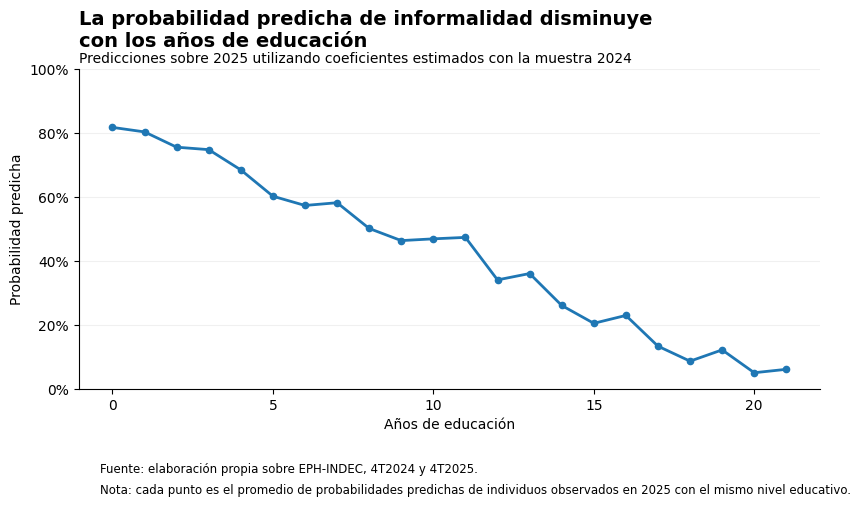

In [36]:

# ============================================================
# B.2 - Probabilidad predicha de informalidad en 2025
# Coeficientes estimados con 2024
# Característica seleccionada: años de educación
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Matriz 2025-MM compatible con el Modelo 1 estimado con 2024
X_2025_para_M1 = sm.add_constant(
    ocupados_2025_MM[X_vars_final].astype(float),
    has_constant="add"
)

# Predicción temporal fuera de muestra: coeficientes 2024 sobre personas 2025
ocupados_2025_MM["p_hat_M1_2025"] = (
    modelo_1_final.predict(X_2025_para_M1)
)

# Probabilidad predicha promedio por años de educación
grafico_educ = (
    ocupados_2025_MM
    .groupby("educ", as_index=False)["p_hat_M1_2025"]
    .mean()
    .sort_values("educ")
)

fig, ax = plt.subplots(figsize=(8.4, 5.2))

ax.plot(
    grafico_educ["educ"],
    grafico_educ["p_hat_M1_2025"],
    marker="o",
    linewidth=2,
    markersize=4.5
)

ax.set_title(
    "La probabilidad predicha de informalidad disminuye\n"
    "con los años de educación",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0, 1.02,
    "Predicciones sobre 2025 utilizando coeficientes estimados con la muestra 2024",
    transform=ax.transAxes,
    fontsize=10
)

ax.set_xlabel("Años de educación")
ax.set_ylabel("Probabilidad predicha")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.grid(axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.125, 0.02,
    "Fuente: elaboración propia sobre EPH-INDEC, 4T2024 y 4T2025.",
    fontsize=8.5
)
fig.text(
    0.125, -0.02,
    "Nota: cada punto es el promedio de probabilidades predichas de individuos "
    "observados en 2025 con el mismo nivel educativo.",
    fontsize=8.5
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])

plt.savefig(
    "/content/figura1_probabilidad_educacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Lectura de la Figura 1

La probabilidad predicha promedio de informalidad disminuye marcadamente con
los años de educación. La curva supera el 80% en los niveles educativos más
bajos y cae por debajo del 25% luego de completar el secundario.

Las oscilaciones locales no deben interpretarse como efectos causales: cada
punto promedia individuos reales que, además de educación, difieren en edad,
horas trabajadas, sexo y composición del hogar. El patrón general es
consistente con la asociación negativa estimada en el Logit.


In [37]:
# ============================================================
# C.1 - Predicción fuera de muestra
# Ambos modelos evaluados sobre las mismas 4.714 personas
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# ------------------------------------------------------------
# M1: coeficientes estimados con 2024
# ------------------------------------------------------------

X_test_M1 = sm.add_constant(
    ocupados_2025_MM[X_vars_final].astype(float),
    has_constant="add"
)

p_M1 = modelo_1_final.predict(X_test_M1)


# ------------------------------------------------------------
# M2: modelo con informalidad previa
# ------------------------------------------------------------

X_test_M2 = sm.add_constant(
    ocupados_2025_MM[X_vars_MM_final].astype(float),
    has_constant="add"
)

p_M2 = modelo_2_final.predict(X_test_M2)

# Valor observado 2025
y_test = ocupados_2025_MM["informal"].astype(int)

print("Observaciones test:", len(y_test))
print("Predicciones M1:", len(p_M1))
print("Predicciones M2:", len(p_M2))

Observaciones test: 4714
Predicciones M1: 4714
Predicciones M2: 4714


In [38]:
# ============================================================
# Clasificación con threshold = 0.5
# ============================================================

umbral = 0.5

y_pred_M1 = (p_M1 > umbral).astype(int)
y_pred_M2 = (p_M2 > umbral).astype(int)

In [39]:
cm_M1 = confusion_matrix(y_test, y_pred_M1)
cm_M2 = confusion_matrix(y_test, y_pred_M2)

print("Matriz de confusión - Modelo 1")
print(cm_M1)

print("\nMatriz de confusión - Modelo MM")
print(cm_M2)

Matriz de confusión - Modelo 1
[[2963  392]
 [ 695  664]]

Matriz de confusión - Modelo MM
[[3122  233]
 [ 204 1155]]


In [40]:
# ============================================================
# Métricas de clasificación
# ============================================================

def metricas_modelo(y_real, y_pred, probabilidades, nombre):

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1": f1_score(y_real, y_pred),
        "AUC": roc_auc_score(y_real, probabilidades)
    }


metricas = pd.DataFrame([
    metricas_modelo(
        y_test,
        y_pred_M1,
        p_M1,
        "Modelo 1"
    ),
    metricas_modelo(
        y_test,
        y_pred_M2,
        p_M2,
        "Modelo MM"
    )
])

display(
    metricas.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}"
    })
)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1,0.769,0.629,0.489,0.550,0.782
1,Modelo MM,0.907,0.832,0.850,0.841,0.928


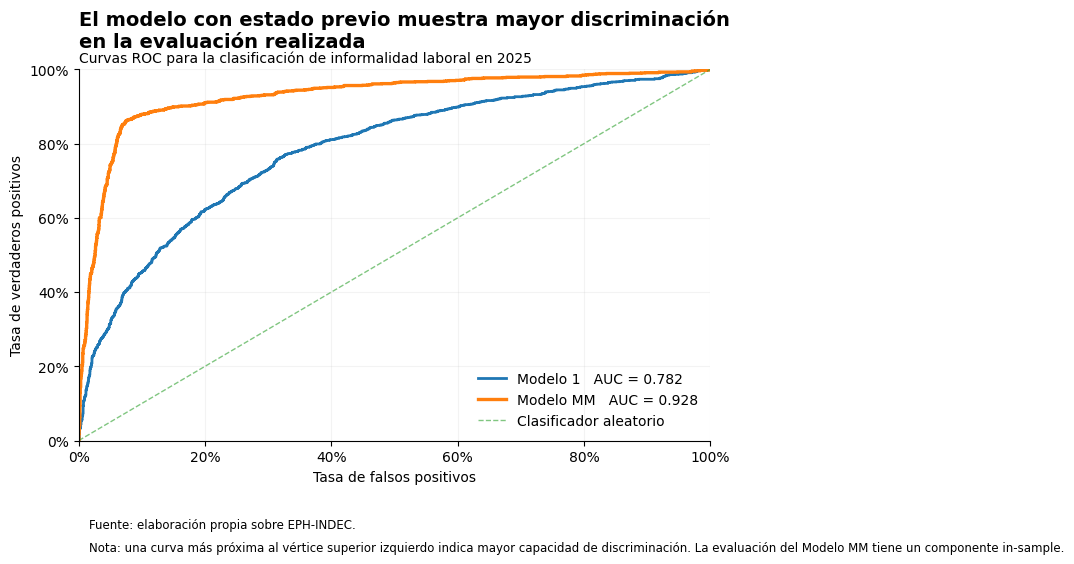

In [41]:

# ============================================================
# C.1 - Curvas ROC
# ============================================================

import matplotlib.ticker as mtick

fpr_M1, tpr_M1, _ = roc_curve(y_test, p_M1)
fpr_M2, tpr_M2, _ = roc_curve(y_test, p_M2)

auc_M1 = roc_auc_score(y_test, p_M1)
auc_M2 = roc_auc_score(y_test, p_M2)

fig, ax = plt.subplots(figsize=(7.5, 5.8))

ax.plot(
    fpr_M1,
    tpr_M1,
    linewidth=2,
    label=f"Modelo 1   AUC = {auc_M1:.3f}"
)

ax.plot(
    fpr_M2,
    tpr_M2,
    linewidth=2.4,
    label=f"Modelo MM   AUC = {auc_M2:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="Clasificador aleatorio"
)

ax.set_title(
    "El modelo con estado previo muestra mayor discriminación\n"
    "en la evaluación realizada",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.text(
    0, 1.02,
    "Curvas ROC para la clasificación de informalidad laboral en 2025",
    transform=ax.transAxes,
    fontsize=10
)

ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.grid(alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")

fig.text(
    0.125, 0.02,
    "Fuente: elaboración propia sobre EPH-INDEC.",
    fontsize=8.5
)
fig.text(
    0.125, -0.02,
    "Nota: una curva más próxima al vértice superior izquierdo indica mayor "
    "capacidad de discriminación. La evaluación del Modelo MM tiene un componente in-sample.",
    fontsize=8.5
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])

plt.savefig(
    "/content/figura3_curvas_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Desempeño predictivo

El Modelo 1 alcanza un AUC de **0,782**, mientras que el Modelo MM alcanza
**0,928** en la evaluación realizada. Con un umbral de 0,5, el recall aumenta
de **0,489** a **0,850**, y los falsos negativos se reducen de **695 a 204**.
La precision también aumenta de **0,629** a **0,832**.

La comparación debe interpretarse con cautela: el Modelo 1 utiliza coeficientes
estimados en 2024 para predecir 2025 y constituye una evaluación temporal fuera
de muestra. El Modelo MM, en cambio, se estima y evalúa sobre la submuestra
longitudinal de 2025, por lo que sus métricas contienen un componente de ajuste
dentro de muestra y pueden ser optimistas respecto de su desempeño sobre datos
nuevos.


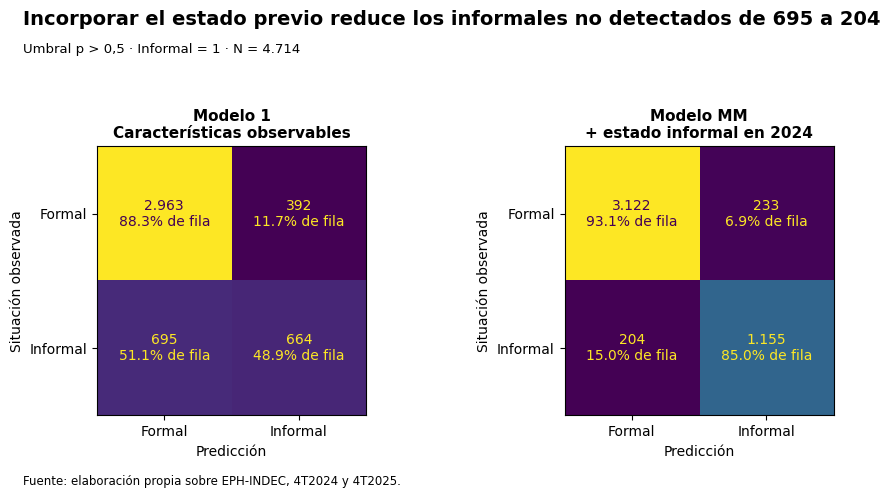

In [42]:

# ============================================================
# C.1 - Matrices de confusión comparadas
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.8))

for ax, cm, titulo in [
    (axes[0], cm_M1, "Modelo 1\nCaracterísticas observables"),
    (axes[1], cm_M2, "Modelo MM\n+ estado informal en 2024")
]:
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Formal", "Informal"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    # Agregamos porcentaje dentro de cada fila sin alterar los conteos
    porcentajes = cm / cm.sum(axis=1, keepdims=True)

    for i in range(2):
        for j in range(2):
            conteo = cm[i, j]
            pct = porcentajes[i, j]
            disp.text_[i, j].set_text(
                f"{conteo:,}\n{pct:.1%} de fila".replace(",", ".")
            )

    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Situación observada")

fig.suptitle(
    "Incorporar el estado previo reduce los informales no detectados de 695 a 204",
    x=0.08,
    ha="left",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.08, 0.89,
    "Umbral p > 0,5 · Informal = 1 · N = 4.714",
    fontsize=9.5
)

fig.text(
    0.08, -0.01,
    "Fuente: elaboración propia sobre EPH-INDEC, 4T2024 y 4T2025.",
    fontsize=8.5
)

plt.tight_layout(rect=[0, 0.05, 1, 0.84])

plt.savefig(
    "/content/figura2_matrices_confusion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Selección del modelo para la política de formalización

Con `informal = 1`, un falso negativo es un trabajador efectivamente informal
que el modelo clasifica como formal; un falso positivo es un trabajador formal
clasificado como informal. Si el objetivo de la política es identificar la
mayor cantidad posible de trabajadores precarizados sin dispersar recursos,
el recall y la precision resultan más informativos que la accuracy aislada.

Al umbral de 0,5, el Modelo MM reduce los falsos negativos de **695 a 204** y
los falsos positivos de **392 a 233**, al tiempo que eleva el recall de
**48,9% a 85,0%** y la precision de **62,9% a 83,2%**. Esta ventaja debe
interpretarse junto con la salvedad de evaluación in-sample señalada arriba.

Además, el Modelo MM sólo puede aplicarse cuando existe información sobre el
estado laboral previo. En una aplicación operativa real, ese historial debería
provenir de registros administrativos longitudinales; la EPH permite evaluar
la lógica predictiva, pero no constituye por sí misma un instrumento de
focalización individual.


In [43]:
# ============================================================
# C.1 - Tabla resumen de desempeño de los modelos
# ============================================================

# Extraemos componentes de las matrices de confusión
tn1, fp1, fn1, tp1 = cm_M1.ravel()
tn2, fp2, fn2, tp2 = cm_M2.ravel()

tabla_desempeno = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo MM"],

    "TN": [tn1, tn2],
    "FP": [fp1, fp2],
    "FN": [fn1, fn2],
    "TP": [tp1, tp2],

    "Accuracy": [
        accuracy_score(y_test, y_pred_M1),
        accuracy_score(y_test, y_pred_M2)
    ],

    "Precision": [
        precision_score(y_test, y_pred_M1),
        precision_score(y_test, y_pred_M2)
    ],

    "Recall": [
        recall_score(y_test, y_pred_M1),
        recall_score(y_test, y_pred_M2)
    ],

    "F1": [
        f1_score(y_test, y_pred_M1),
        f1_score(y_test, y_pred_M2)
    ],

    "AUC": [
        roc_auc_score(y_test, p_M1),
        roc_auc_score(y_test, p_M2)
    ]
})

display(
    tabla_desempeno.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}"
    })
)

,Modelo,TN,FP,FN,TP,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1,2963,392,695,664,0.769,0.629,0.489,0.550,0.782
1,Modelo MM,3122,233,204,1155,0.907,0.832,0.850,0.841,0.928


In [44]:
# ============================================================
# Tasas de error Tipo I y Tipo II
# ============================================================

tabla_desempeno["FPR"] = [
    fp1 / (fp1 + tn1),
    fp2 / (fp2 + tn2)
]

tabla_desempeno["FNR"] = [
    fn1 / (fn1 + tp1),
    fn2 / (fn2 + tp2)
]

display(
    tabla_desempeno.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "AUC": "{:.3f}",
        "FPR": "{:.3f}",
        "FNR": "{:.3f}"
    })
)

,Modelo,TN,FP,FN,TP,Accuracy,Precision,Recall,F1,AUC,FPR,FNR
0,Modelo 1,2963,392,695,664,0.769,0.629,0.489,0.550,0.782,0.117,0.511
1,Modelo MM,3122,233,204,1155,0.907,0.832,0.850,0.841,0.928,0.069,0.150
